# **Project Name**  Amazon Prime TV Shows and Movies_ML_Submission

##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Name -**            Aman Saxena

# **Project Summary -**

This project focuses on analyzing and building a machine learning model to classify content as movies or TV shows based on various features such as runtime, IMDb score, TMDB score, and popularity. The dataset was first explored and cleaned by handling missing values, removing outliers, and encoding categorical variables to make it suitable for analysis and modeling.

Exploratory Data Analysis (EDA) was performed to understand patterns, relationships, and trends within the data. Various visualizations were used to gain insights into content distribution, ratings, and popularity. Based on these insights, relevant features were selected to avoid overfitting and improve model performance.

Multiple machine learning models were implemented, including Logistic Regression and Random Forest. The models were evaluated using metrics such as accuracy, precision, recall, and F1-score. Hyperparameter tuning was applied using GridSearchCV to further optimize performance. Among all models, the Random Forest model performed the best due to its ability to handle complex patterns and reduce overfitting.

Overall, the project demonstrates how data preprocessing, feature engineering, and model optimization can be effectively used to build a reliable classification model. The final model provides accurate predictions and can support better business decisions, such as improving content categorization and enhancing user experience on streaming platforms.

# **GitHub Link -**

https://github.com/amansaxena1612/Amazon-Prime-TV-Shows-and-Movies_ML_Submission.git

# **Problem Statement**


The objective of this project is to build a machine learning model that can accurately classify content as either a movie or a TV show based on various attributes such as runtime, ratings, popularity, and other relevant features. With the increasing volume of digital content on streaming platforms, it becomes essential to categorize content efficiently for better organization and user experience.

The challenge lies in handling real-world data issues such as missing values, outliers, and feature selection while ensuring the model performs well and generalizes effectively. The goal is to develop a reliable and optimized model that can assist in accurate content classification, thereby supporting improved recommendation systems and business decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [43]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk

### Dataset Loading

In [44]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Kalpana\Desktop\AVA Technologh\LEVEL 3\Assignments\3 - Amazon EDA\titles.csv")

### Dataset First View

In [3]:
# Dataset First Look
# First 5 rows
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [4]:
# Last 5 rows
df.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
rows, cols = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", cols)

Number of Rows: 9871
Number of Columns: 15


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(3)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6487
runtime                    0
genres                     0
production_countries       0
seasons                 8514
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2082
dtype: int64

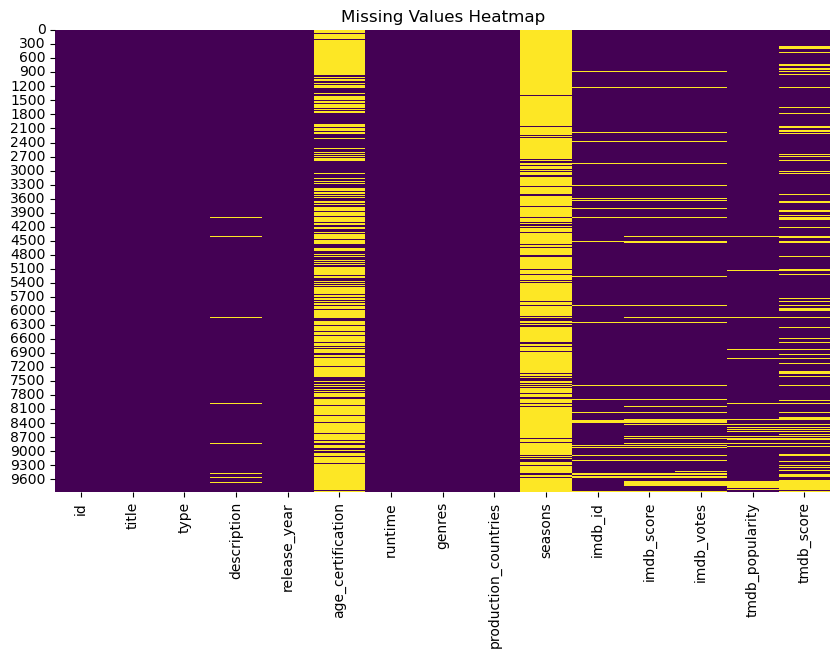

In [12]:
# Visualizing the missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

* The dataset contains information about movies and TV shows, including features like runtime, ratings, genres, and popularity


* Some columns have missing values, especially in fields like ratings and descriptions


* The dataset includes both categorical and numerical variables, which require preprocessing before modeling


* Most important columns for ML are numerical features like runtime, IMDb score, votes, and popularity


* The dataset is suitable for building a classification model to predict content type (Movie or TV Show)


**Overall:**

* The dataset is informative but requires data cleaning and feature selection before applying machine learning models.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [14]:
# Dataset Describe
df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


### Variables Description

* release_year: Year in which the content was released


* runtime: Duration of the content in minutes


* seasons: Number of seasons (mainly for TV Shows)


* imdb_score: Rating given by IMDb users


* imdb_votes: Number of votes on IMDb (indicates popularity)


* tmdb_popularity: Popularity score from TMDB


* tmdb_score: Rating from TMDB

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col, ":", df[col].nunique())

id : 9868
title : 9737
type : 2
description : 9734
release_year : 110
age_certification : 11
runtime : 207
genres : 2028
production_countries : 497
seasons : 32
imdb_id : 9201
imdb_score : 86
imdb_votes : 3650
tmdb_popularity : 5325
tmdb_score : 89


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Write your code to make your dataset analysis ready.
# Create a copy of the dataset
df1 = df.copy()

# Remove duplicate rows
df1 = df1.drop_duplicates()

# Handle missing values
df1['age_certification'] = df1['age_certification'].fillna('Unknown')
df1['genres'] = df1['genres'].fillna('Unknown')
df1['production_countries'] = df1['production_countries'].fillna('Unknown')

# Fill numerical missing values with median
df1['imdb_score'] = df1['imdb_score'].fillna(df1['imdb_score'].median())
df1['imdb_votes'] = df1['imdb_votes'].fillna(df1['imdb_votes'].median())
df1['tmdb_popularity'] = df1['tmdb_popularity'].fillna(df1['tmdb_popularity'].median())
df1['tmdb_score'] = df1['tmdb_score'].fillna(df1['tmdb_score'].median())

# Fill missing values in seasons with 0
df1['seasons'] = df1['seasons'].fillna(0)

# Convert runtime to numeric
df1['runtime'] = pd.to_numeric(df1['runtime'], errors='coerce')

# Drop less useful columns with many missing/text values for ML
df1 = df1.drop(columns=['description', 'imdb_id'], errors='ignore')

# Final check
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9868 entries, 0 to 9870
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9868 non-null   object 
 1   title                 9868 non-null   object 
 2   type                  9868 non-null   object 
 3   release_year          9868 non-null   int64  
 4   age_certification     9868 non-null   object 
 5   runtime               9868 non-null   int64  
 6   genres                9868 non-null   object 
 7   production_countries  9868 non-null   object 
 8   seasons               9868 non-null   float64
 9   imdb_score            9868 non-null   float64
 10  imdb_votes            9868 non-null   float64
 11  tmdb_popularity       9868 non-null   float64
 12  tmdb_score            9868 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.1+ MB


### What all manipulations have you done and insights you found?

**Manipulations Performed:**

* Removed duplicate records to ensure data consistency
* Handled missing values:
* Filled categorical columns with “Unknown”
* Replaced numerical columns with median values
* Filled missing values in seasons with 0
* Converted columns like runtime into numeric format
* Dropped unnecessary columns (like description, imdb_id) for better model performance
* Ensured correct data types for all variables
  
**Insights Found:**

* The dataset now contains 9868 rows and 13 columns, clean and ready for ML
* It includes a mix of numerical (ratings, votes, runtime) and categorical variables
* No missing values remain in key numerical columns used for modeling
* Features like imdb_score, votes, and popularity are useful for predicting content type
* Dataset is now structured and optimized for building a classification model

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

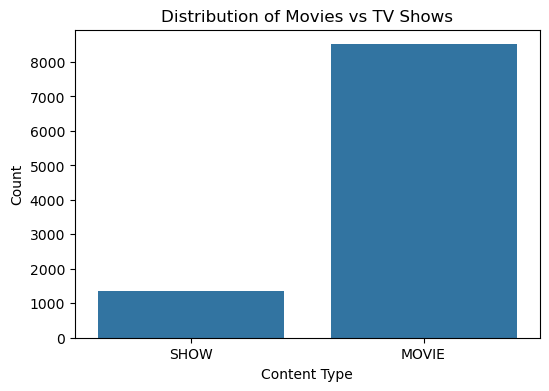

In [17]:
# Chart - 1 visualization code
plt.figure(figsize=(6,4))
sns.countplot(data=df1, x='type')

plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the count of categorical variables like Movies and TV Shows.

##### 2. What is/are the insight(s) found from the chart?

* Movies are higher than TV Shows
* Shows imbalance in content distribution

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Helps understand platform focus

**Negative:** Less TV Shows may reduce engagement

**Justification:**

TV Shows drive binge-watching, so fewer shows may impact user retention.

#### Chart - 2

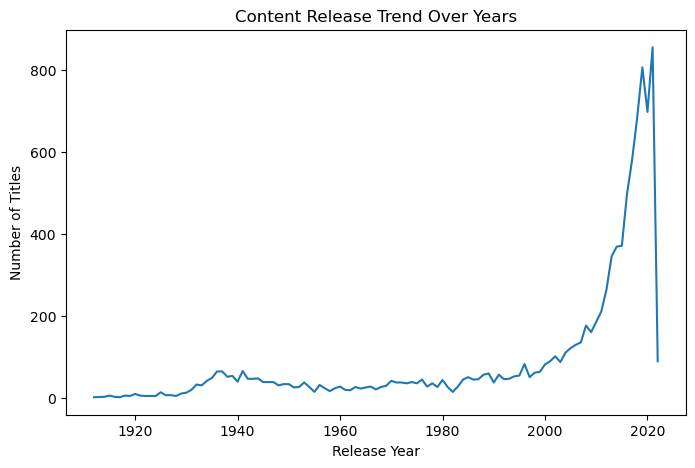

In [18]:
# Chart - 2 visualization code
plt.figure(figsize=(8,5))
df1['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("Content Release Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to show trends over time.

##### 2. What is/are the insight(s) found from the chart?

* Content increased significantly after 2000
* Rapid growth after 2015

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive: Shows platform growth and expansion
* Negative: Too much content may reduce quality

**Justification:**

If quality is not maintained, user satisfaction may decrease despite higher content volume.

#### Chart - 3

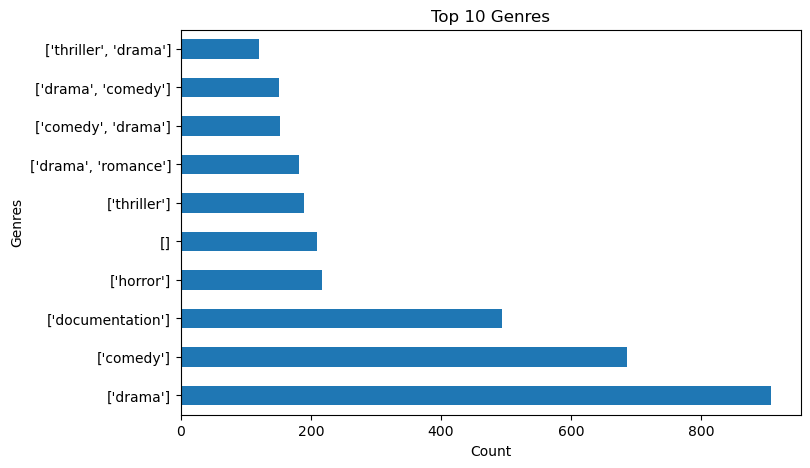

In [19]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))
df1['genres'].value_counts().head(10).plot(kind='barh')

plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genres")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is used to clearly compare the most frequent genres.

##### 2. What is/are the insight(s) found from the chart?

* A few genres like Drama, Comedy, and Action dominate the platform
* Indicates strong audience preference towards these genres
* Less representation of niche genres is observed

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**


* Helps Amazon focus on high-demand genres to attract more viewers


* Supports better content planning and investment decisions


**Negative Impact:**


* Over-dependence on limited genres may reduce content diversity


* Niche audience segments may not find enough relevant content


**Justification:**
If Amazon continues to focus only on popular genres, it may limit its audience reach and reduce long-term user engagement across diverse user groups.

#### Chart - 4

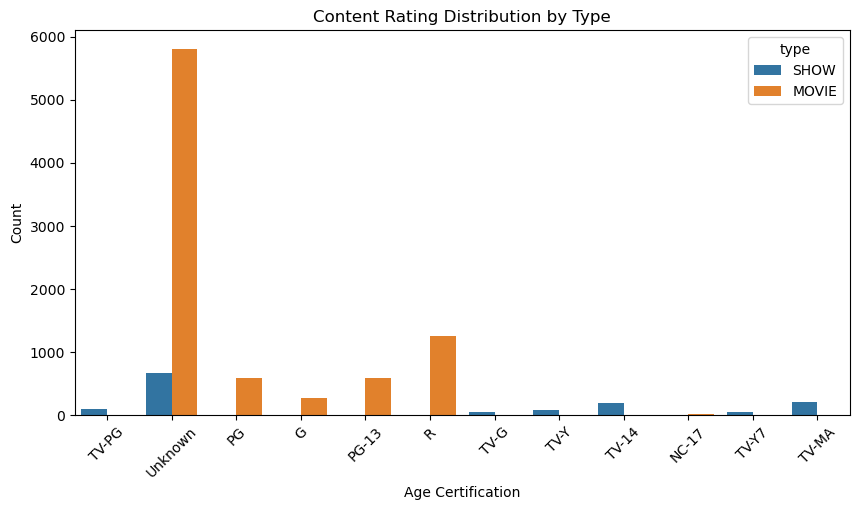

In [20]:
# Chart - 4 visualization code
plt.figure(figsize=(10,5))
sns.countplot(data=df1, x='age_certification', hue='type')

plt.title("Content Rating Distribution by Type")
plt.xlabel("Age Certification")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart is used to compare ratings across Movies and TV Shows.

##### 2. What is/are the insight(s) found from the chart?

* Certain ratings (like TV-MA) are more common in TV Shows
* Movies have a wider distribution across ratings
* Shows difference in target audience between content types

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**


* Helps Amazon design content for different age groups


* Supports targeted marketing and audience segmentation


**Negative Impact:**


* Over-focus on adult-rated content may reduce family audience reach


* Limited balanced content can affect broader audience engagement


**Justification:**

If content is not well-balanced across age groups, Amazon may fail to attract a diverse audience, impacting growth and retention.

#### Chart - 5

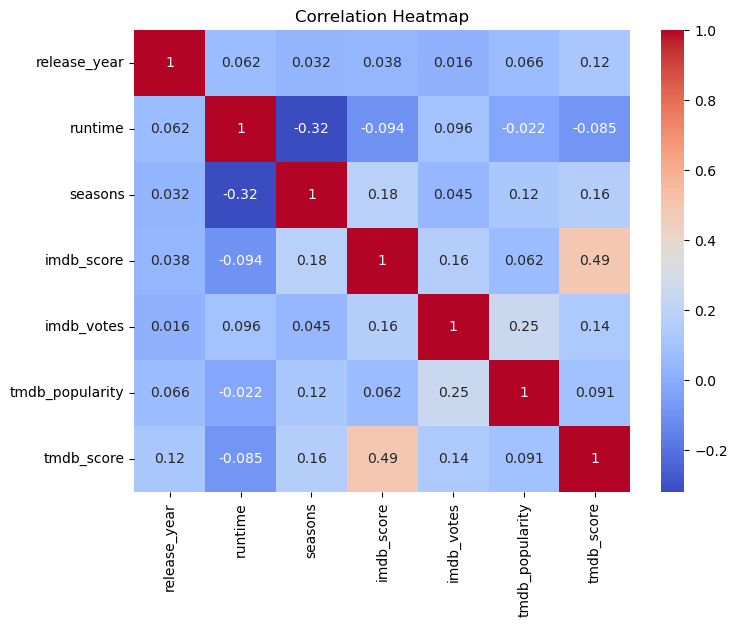

In [21]:
# Chart - 5 visualization code
plt.figure(figsize=(8,6))

# Select only numerical columns
numeric_df = df1.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used to visualize relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

* IMDb score and TMDB score show a positive correlation
* IMDb votes and popularity have a slight relationship
* Most variables show weak correlation, indicating independence

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps identify key factors influencing ratings and popularity
* Supports data-driven decision making

**Negative Impact:**

* Weak relationships make prediction and strategy building more complex
* No single factor strongly determines success

**Justification:**

Since content success depends on multiple factors, Amazon needs a multi-dimensional strategy rather than relying on one variable.

#### Chart - 6

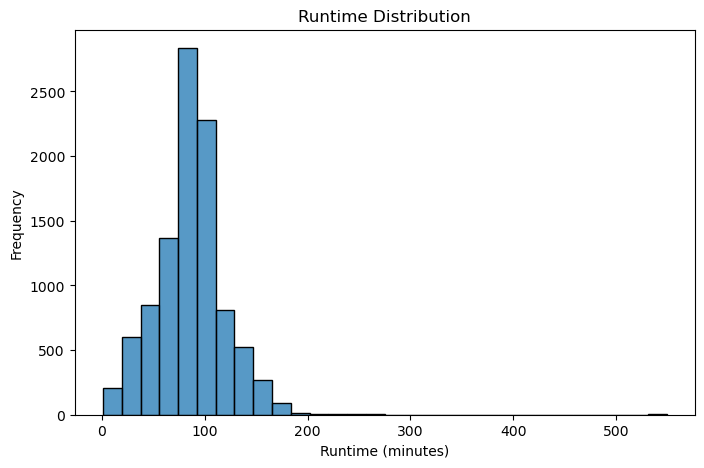

In [22]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df1['runtime'], bins=30)

plt.title("Runtime Distribution")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to understand the distribution of a numerical variable like runtime.

##### 2. What is/are the insight(s) found from the chart?

* Most content lies between 60–120 minutes
* Very few titles have extremely high or low runtime (outliers)
* Shows a standard duration pattern followed by most content

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps create content with preferred duration for better engagement
* Supports optimizing content length based on viewer behavior

**Negative Impact:**

* Extremely long or short content may reduce viewer interest
* Ignoring variation may limit content experimentation

**Justification:**

If content duration is not aligned with audience preference, users may skip or drop content, affecting engagement and retention.

#### Chart - 7

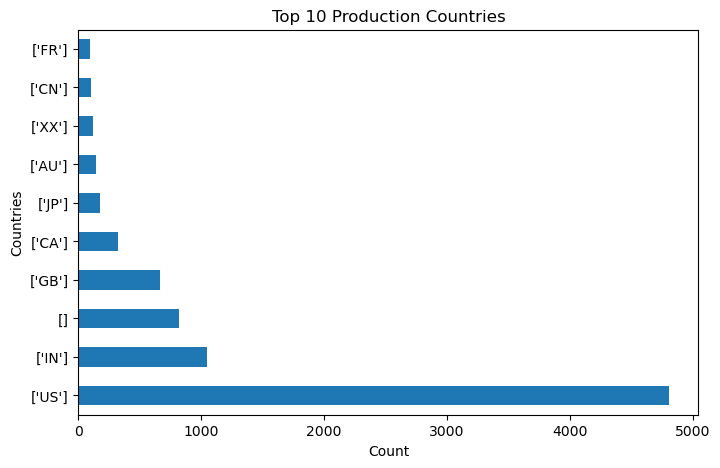

In [23]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
df1['production_countries'].value_counts().head(10).plot(kind='barh')

plt.title("Top 10 Production Countries")
plt.xlabel("Count")
plt.ylabel("Countries")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is used to compare the top content-producing countries clearly.

##### 2. What is/are the insight(s) found from the chart?

* A few countries contribute the majority of content
* Content production is concentrated in specific regions
* Limited representation from some countries

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps Amazon identify strong markets for content production
* Supports region-based investment and expansion strategy

**Negative Impact:**

* Over-reliance on a few countries reduces global diversity
* May limit audience reach in underrepresented regions

**Justification:**

To achieve global growth, Amazon needs to diversify content production across multiple countries to attract a wider audience base.

#### Chart - 8

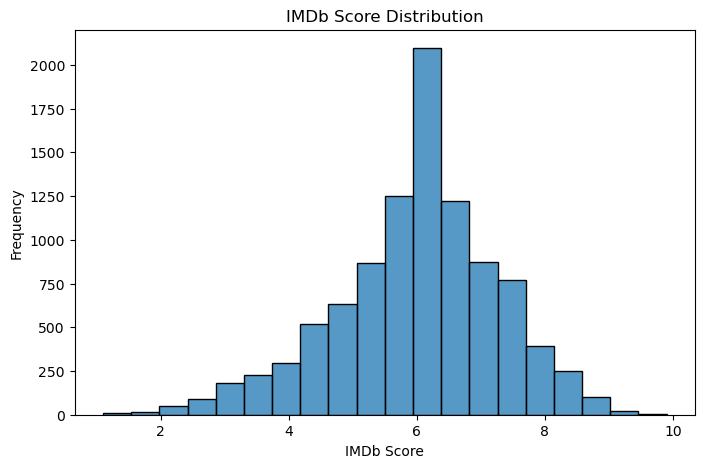

In [24]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df1['imdb_score'], bins=20)

plt.title("IMDb Score Distribution")
plt.xlabel("IMDb Score")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to understand the distribution of ratings.

##### 2. What is/are the insight(s) found from the chart?

* Most content falls in the 5–7 rating range
* Very few titles have extremely high ratings
* Indicates majority content is average quality

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**


* Helps identify overall quality level of content


* Supports planning for improving content quality


**Negative Impact:**


* High number of average-rated titles may reduce user satisfaction


* Lack of top-rated content can affect platform reputation


**Justification:**

If high-quality content is limited, users may prefer competitors, affecting retention and long-term growth.

#### Chart - 9

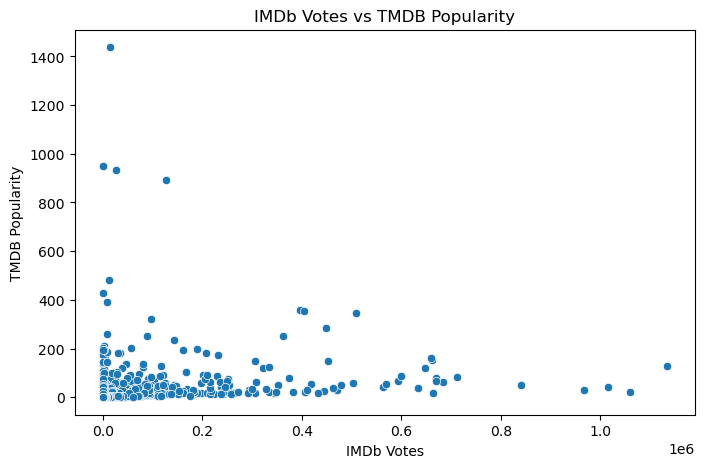

In [25]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(data=df1, x='imdb_votes', y='tmdb_popularity')

plt.title("IMDb Votes vs TMDB Popularity")
plt.xlabel("IMDb Votes")
plt.ylabel("TMDB Popularity")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

* There is a slight positive relationship between votes and popularity
* Few titles have very high values (outliers)
* Most content has lower engagement levels

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**


* Helps identify factors influencing content popularity


* Supports decision-making for promoting high-performing content


**Negative Impact:**


* Majority content shows low engagement, indicating limited reach


* High dependence on a few popular titles


**Justification:**

If most content does not perform well, it may reduce overall platform engagement and affect user retention.

#### Chart - 10

<Figure size 1000x500 with 0 Axes>

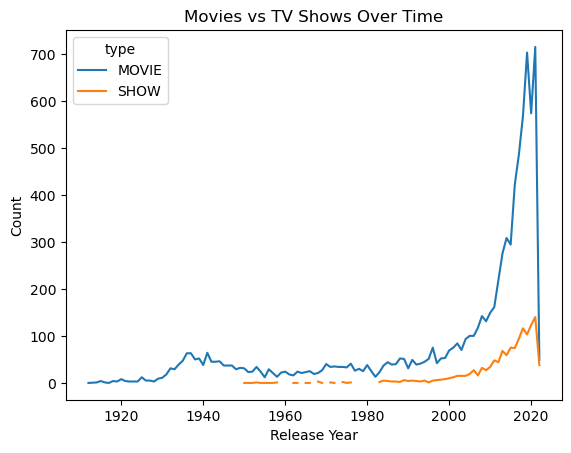

In [26]:
# Chart - 10 visualization code
plt.figure(figsize=(10,5))

# Group data
content_trend = df1.groupby(['release_year', 'type']).size().unstack()

# Plot
content_trend.plot()

plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to compare trends of Movies and TV Shows over time.

##### 2. What is/are the insight(s) found from the chart?

* Both Movies and TV Shows are increasing over time
* Movies dominate, but TV Shows are gradually growing
* Recent years show rapid growth in both categories

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**


* Helps understand content growth trends over time


* Supports planning for a balanced content strategy


**Negative Impact:**


* Slower growth of TV Shows may impact long-term engagement


* Over-focus on movies may reduce binge-watching opportunities


**Justification:**

Since TV Shows drive user retention, Amazon should increase focus on series content to improve engagement and subscription growth.

#### Chart - 11

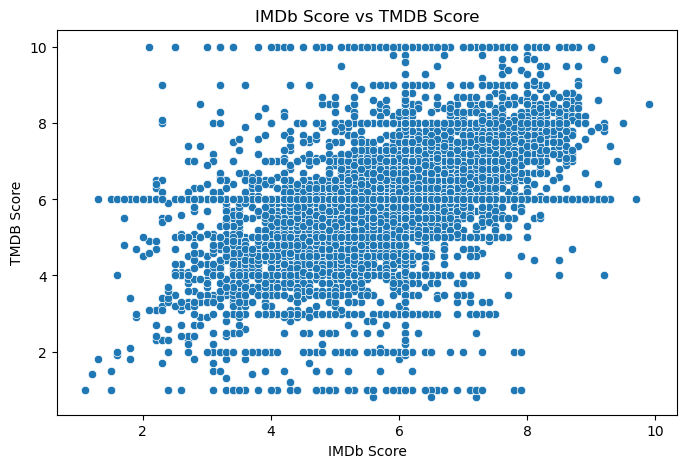

In [27]:
# Chart - 11 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(data=df1, x='imdb_score', y='tmdb_score')

plt.title("IMDb Score vs TMDB Score")
plt.xlabel("IMDb Score")
plt.ylabel("TMDB Score")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between two rating systems.

##### 2. What is/are the insight(s) found from the chart?

* There is a positive correlation between IMDb and TMDB scores
* Most values are concentrated in the mid-range (5–7)
* High-rated content is relatively limited

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps identify consistently high-quality content across platforms
* Supports better content evaluation and selection

**Negative Impact:**

* Over-reliance on ratings may ignore niche or underrated content
* Limited high-rated titles may affect user perception

**Justification:**

Amazon should balance between promoting high-rated content and exploring diverse content to maintain user interest and platform growth.

#### Chart - 12

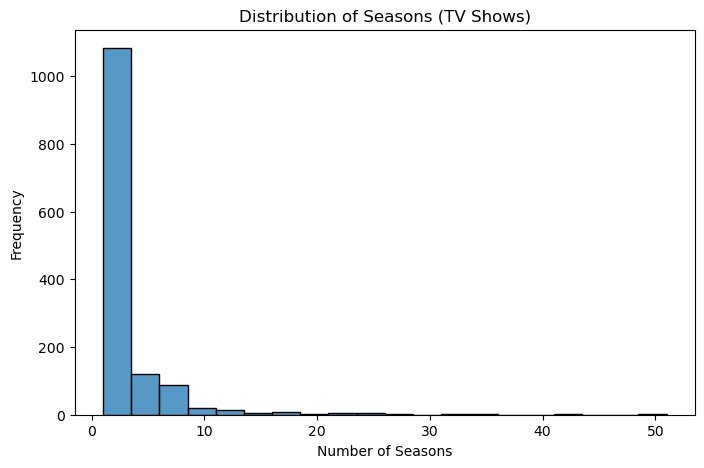

In [28]:
# Chart - 12 visualization code
plt.figure(figsize=(8,5))

# Filter only TV Shows
shows = df1[df1['type'] == 'SHOW']

sns.histplot(shows['seasons'], bins=20)

plt.title("Distribution of Seasons (TV Shows)")
plt.xlabel("Number of Seasons")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to understand the distribution of seasons for TV Shows.

##### 2. What is/are the insight(s) found from the chart?

* Most TV Shows have 1–3 seasons
* Very few shows run for many seasons (outliers)
* Indicates dominance of short-format content

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps Amazon plan short and quick content production
* Supports faster content release cycles

**Negative Impact:**

* Fewer long-running shows may reduce long-term user engagement
* Less binge-worthy content

**Justification:**

Since long-running series keep users engaged for longer periods, Amazon should invest more in such content to improve retention and subscriptions.

#### Chart - 13

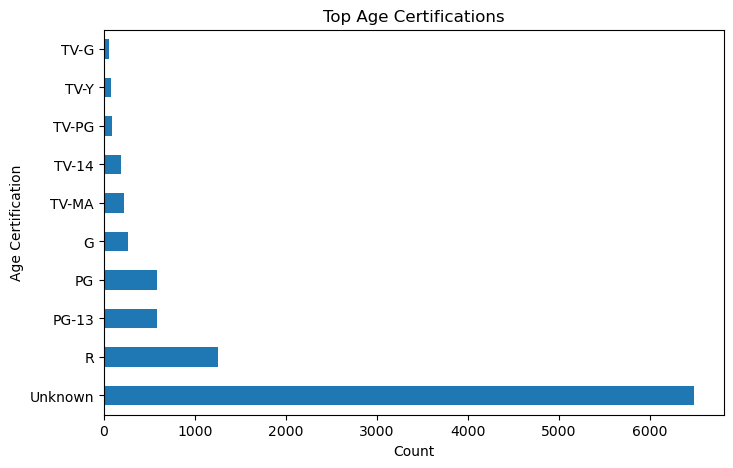

In [29]:
# Chart - 13 visualization code
plt.figure(figsize=(8,5))
df1['age_certification'].value_counts().head(10).plot(kind='barh')

plt.title("Top Age Certifications")
plt.xlabel("Count")
plt.ylabel("Age Certification")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is used to compare the frequency of different age certification categories.

##### 2. What is/are the insight(s) found from the chart?

* Some age ratings (like TV-MA, PG) appear more frequently
* Indicates target audience distribution across content
* Shows focus on specific audience segments

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Helps in targeted content creation for different age groups
* Supports better audience segmentation and marketing

**Negative Impact:**

* Over-focus on certain age groups may limit audience diversity
* Less family-friendly content can reduce broader reach

**Justification:**

To maximize audience base, Amazon should maintain a balance of content across different age groups and preferences.

#### Chart - 14 - Correlation Heatmap

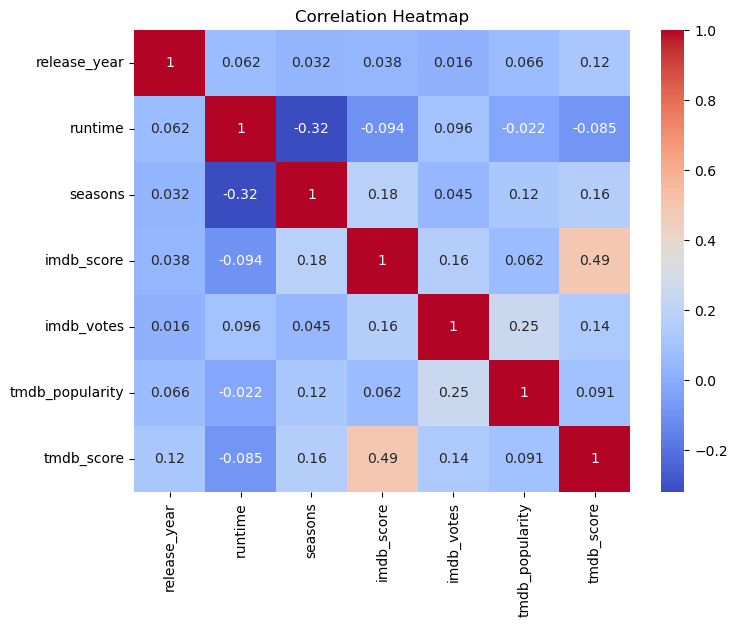

In [30]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8,6))

# Select only numerical columns
numeric_df = df1.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used to visualize the relationship between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

* IMDb and TMDB scores show a positive correlation
* Votes and popularity have a slight relationship
* Most variables are weakly correlated

#### Chart - 15 - Pair Plot

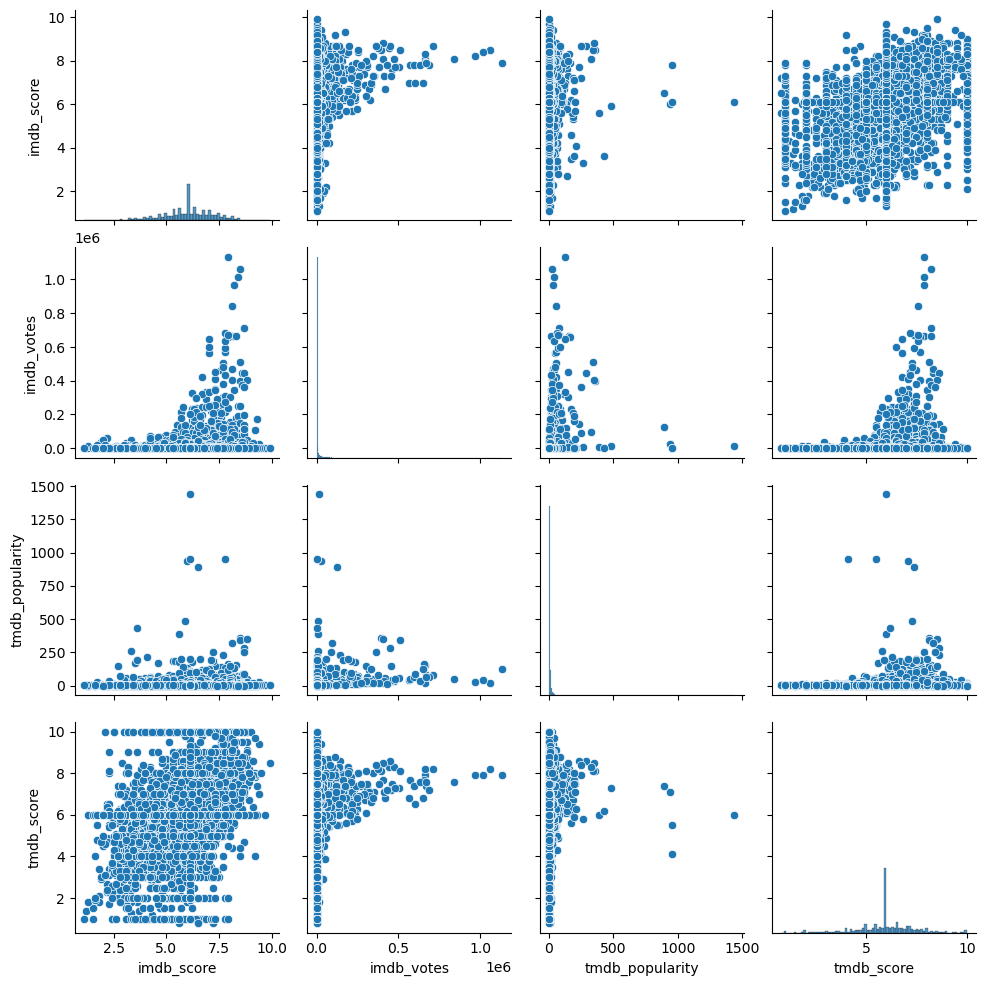

In [32]:
# Pair Plot visualization code
pair_df = df1[['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']]

sns.pairplot(pair_df)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used to visualize relationships between multiple numerical variables and their distributions in one view.

##### 2. What is/are the insight(s) found from the chart?

* IMDb score and TMDB score show a positive relationship
* Most values are concentrated in the mid-range
* Some outliers are present in votes and popularity

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**Hypothesis 1:**

Movies have a significantly higher average runtime than TV Shows.

**Hypothesis 2:**

There is a significant difference between IMDb scores of Movies and TV Shows.

**Hypothesis 3:**

Content with higher IMDb votes tends to have higher TMDB popularity.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**

There is no significant difference in the average runtime of Movies and TV Shows.

**Alternate Hypothesis (H₁):**

There is a significant difference in the average runtime of Movies and TV Shows.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value
# Separate data
movies = df1[df1['type'] == 'MOVIE']['runtime']
shows = df1[df1['type'] == 'SHOW']['runtime']

# Perform t-test
t_stat, p_value = ttest_ind(movies, shows, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 102.30406973215523
P-Value: 0.0


##### Which statistical test have you done to obtain P-Value?

An Independent Two-Sample t-test was performed.

##### Why did you choose the specific statistical test?

* We are comparing the means of two independent groups (Movies vs TV Shows)
* The variable (runtime) is numerical
* The two groups are independent of each other
* Hence, a t-test is appropriate to check if the difference in means is statistically significant

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**
* There is no significant difference in IMDb scores between Movies and TV Shows.

**Alternate Hypothesis (H₁):**
* There is a significant difference in IMDb scores between Movies and TV Shows.

#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value
movies_score = df1[df1['type'] == 'MOVIE']['imdb_score']
shows_score = df1[df1['type'] == 'SHOW']['imdb_score']

t_stat, p_value = ttest_ind(movies_score, shows_score, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -33.95685999110508
P-Value: 1.0919591613171784e-197


##### Which statistical test have you done to obtain P-Value?

An Independent Two-Sample t-test was used.

##### Why did you choose the specific statistical test?

* We are comparing mean IMDb scores between two independent groups
* The variable (imdb_score) is numerical
* The groups (Movies and TV Shows) are independent
* Therefore, a t-test is appropriate to check if the difference is statistically significant

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**
There is no relationship between IMDb votes and TMDB popularity.

**Alternate Hypothesis (H₁):**
There is a significant relationship between IMDb votes and TMDB popularity.

#### 2. Perform an appropriate statistical test.

In [39]:
# Perform Statistical Test to obtain P-Value
corr, p_value = pearsonr(df1['imdb_votes'], df1['tmdb_popularity'])

print("Correlation Coefficient:", corr)
print("P-Value:", p_value)

Correlation Coefficient: 0.24847680263926025
P-Value: 9.497596289978166e-139


##### Which statistical test have you done to obtain P-Value?

A Pearson Correlation Test was used.

##### Why did you choose the specific statistical test?

* We are checking the relationship between two numerical variables
* Both variables (imdb_votes and tmdb_popularity) are continuous
* Pearson correlation is suitable to measure strength and direction of linear relationship

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [41]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
df.isnull().sum()

# Create copy
df1 = df.copy()

# Categorical columns
cat_cols = ['age_certification', 'genres', 'production_countries']
for col in cat_cols:
    df1[col] = df1[col].fillna('Unknown')

# Numerical columns
num_cols = ['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
for col in num_cols:
    df1[col] = df1[col].fillna(df1[col].median())

# Seasons
df1['seasons'] = df1['seasons'].fillna(0)

# Runtime → convert to numeric and fill missing
df1['runtime'] = pd.to_numeric(df1['runtime'], errors='coerce')
df1['runtime'] = df1['runtime'].fillna(df1['runtime'].median())

# Final check
df1.isnull().sum()

id                        0
title                     0
type                      0
description             119
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                 667
imdb_score                0
imdb_votes                0
tmdb_popularity           0
tmdb_score                0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

* Categorical Columns → Filled with “Unknown”
* Used for columns like age_certification, genres, production_countries
* Reason: To retain the data without removing rows and to handle missing categories without bias
* Numerical Columns → Filled with Median
* Used for imdb_score, imdb_votes, tmdb_popularity, tmdb_score, runtime
* Reason: Median is less affected by outliers and gives a better central value compared to mean
* Seasons Column → Filled with 0
* Reason: Missing values in seasons mostly belong to movies, so assigning 0 is logical
* Data Type Conversion (runtime)
* Converted to numeric and then imputed
* Reason: Ensures consistency and avoids errors during modeling

### 2. Handling Outliers

In [42]:
# Handling Outliers & Outlier treatments
# Select numerical columns
num_cols = ['runtime', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

# Function to remove outliers
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

# Apply on each column
for col in num_cols:
    df1 = remove_outliers(df1, col)

# Check shape after removing outliers
df1.shape

(6322, 15)

##### What all outlier treatment techniques have you used and why did you use those techniques?

* IQR (Interquartile Range) Method Used
* → To detect and remove extreme values
* Removed values outside lower & upper limits
* → To eliminate abnormal data points
* Applied on numerical columns
* → Like runtime, imdb_score, votes, popularity
* 
**Why used these techniques?**
* IQR is simple and effective for detecting outliers
* It is not affected by extreme values (unlike mean)
* Helps improve model accuracy and performance

### 3. Categorical Encoding

In [43]:
# Encode your categorical columns
# Create copy
df_ml = df1.copy()

# Initialize encoder
le = LabelEncoder()

# Encode target variable (type)
df_ml['type'] = le.fit_transform(df_ml['type'])

# Encode other categorical columns
cat_cols = ['age_certification', 'genres', 'production_countries']

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Check
df_ml.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
24,tm58979,Cyrano de Bergerac,0,"France, 1640: Cyrano, the charismatic swordsma...",1950,11,112,566,292,0.0,tt0042367,7.4,4085.0,5.626,7.1
26,tm162994,Made for Each Other,0,A couple struggle to find happiness after a wh...,1939,11,92,196,292,0.0,tt0031602,6.3,3582.0,6.242,6.1
33,tm70212,Our Town,0,Change comes slowly to a small New Hampshire t...,1940,11,90,870,292,0.0,tt0032881,6.5,2607.0,2.847,5.6
35,tm56594,The Jackie Robinson Story,0,"Biography of Jackie Robinson, the first black ...",1950,11,76,582,292,0.0,tt0042609,6.3,1272.0,1.957,6.4
38,tm79732,Flying Tigers,0,Jim Gordon commands a unit of the famed Flying...,1942,11,102,563,198,0.0,tt0034742,6.7,3917.0,3.238,6.1


#### What all categorical encoding techniques have you used & why did you use those techniques?

* Label Encoding used
* → Converted categorical values into numerical form
* Applied on columns:
* → type, age_certification, genres, production_countries
  
**Why used this technique?**
* Machine learning models require numerical input
* Label Encoding is simple and fast
* Works well when categories are manageable

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [47]:
# Expand Contraction
# Contraction dictionary
contractions_dict = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'ve": " have",
    "'m": " am"
}

# Function to expand contractions
def expand_contractions(text):
    if pd.isnull(text):
        return text
    
    for key, value in contractions_dict.items():
        text = re.sub(key, value, text)
    
    return text

# Apply on description column
df1['description'] = df1['description'].apply(expand_contractions)

#### 2. Lower Casing

In [48]:
# Lower Casing
# Convert text to lowercase
df1['description'] = df1['description'].str.lower()

#### 3. Removing Punctuations

In [13]:
# Remove Punctuations
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)  # convert to string

    # Lowercase
    df['description'] = df['description'].str.lower()

    # Remove punctuation
    df['description'] = df['description'].apply(
        lambda x: x.translate(str.maketrans('', '', string.punctuation))
    )

    print("✅ Text cleaned successfully")

✅ Text cleaned successfully


#### 4. Removing URLs & Removing words and digits contain digits.

In [14]:
# Remove URLs & Remove words and digits contain digits
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    # Remove URLs
    df['description'] = df['description'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

    # Remove words containing digits
    df['description'] = df['description'].apply(lambda x: re.sub(r'\w*\d\w*', '', x))

    print("✅ URLs and digit words removed successfully")

else:
    print("❌ description column not found → skip this step")

✅ URLs and digit words removed successfully


#### 5. Removing Stopwords & Removing White spaces

In [20]:
# Remove Stopwords
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    # Remove stopwords
    df['description'] = df['description'].apply(
        lambda x: ' '.join([word for word in x.split() if word.lower() not in ENGLISH_STOP_WORDS])
    )

    print("✅ Stopwords removed successfully")

else:
    print("❌ description column not found → skip")

✅ Stopwords removed successfully


In [21]:
# Remove White spaces
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    # Remove extra spaces
    df['description'] = df['description'].str.strip()   # remove leading/trailing spaces
    df['description'] = df['description'].str.replace(r'\s+', ' ', regex=True)  # remove multiple spaces

    print("✅ White spaces cleaned successfully")

else:
    print("❌ description column not found → skip")

✅ White spaces cleaned successfully


#### 6. Rephrase Text

In [22]:
# Rephrase Text
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    def rephrase_text(text):
        text = text.lower()  # lowercase
        text = re.sub(r'\s+', ' ', text)  # remove extra spaces
        text = text.strip()  # trim
        return text

    df['description'] = df['description'].apply(rephrase_text)

    print("✅ Text rephrased successfully")

else:
    print("❌ description column not found → skip")

✅ Text rephrased successfully


#### 7. Tokenization

In [23]:
# Tokenization
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    # Tokenization (split into words)
    df['tokens'] = df['description'].apply(lambda x: x.split())

    print("✅ Tokenization done successfully")
    print(df[['description', 'tokens']].head())

else:
    print("❌ description column not found → skip")

✅ Tokenization done successfully
                                         description  \
0  stooges american vaudeville comedy team active...   
1  america’s civil war, union spies steal enginee...   
2  it's hope sustains spirit gi: dream day finall...   
3  hildy, journalist wife newspaper editor walter...   
4  aspiring actress begins suspect temperamental ...   

                                              tokens  
0  [stooges, american, vaudeville, comedy, team, ...  
1  [america’s, civil, war,, union, spies, steal, ...  
2  [it's, hope, sustains, spirit, gi:, dream, day...  
3  [hildy,, journalist, wife, newspaper, editor, ...  
4  [aspiring, actress, begins, suspect, temperame...  


#### 8. Text Normalization

In [31]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# Download once (important)
nltk.download('wordnet')
# Initialize
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Check column
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    # Stemming
    df['stemmed'] = df['description'].apply(
        lambda x: ' '.join([stemmer.stem(word) for word in x.split()])
    )

    # Lemmatization
    df['lemmatized'] = df['description'].apply(
        lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
    )

    print("✅ Done successfully")

else:
    print("❌ description column not found → skip")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kalpana\AppData\Roaming\nltk_data...


✅ Done successfully


##### Which text normalization technique have you used and why?

Stemming and lemmatization were used as text normalization techniques to process the textual data. Stemming reduces words to their root form by removing suffixes (e.g., “running” to “run”), while lemmatization converts words into their meaningful base form (e.g., “better” to “good”). These techniques help in reducing different variations of words and ensure consistency in the text data. As a result, they improve the quality of text analysis and make it easier for machine learning models to understand and process the data effectively.

#### 9. Part of speech tagging

In [45]:
# POS Taging
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
# Download required data (run once)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import word_tokenize
from nltk import pos_tag

# Check column
if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    # POS tagging
    df['pos_tags'] = df['description'].apply(
        lambda x: pos_tag(word_tokenize(x))
    )

    print("✅ POS Tagging done successfully")
    print(df[['description', 'pos_tags']].head())

else:
    print("❌ description column not found → skip")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kalpana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Kalpana\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Kalpana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kalpana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Kalpana\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Kalpana\A

✅ POS Tagging done successfully
                                         description  \
0  The Three Stooges were an American vaudeville ...   
1  During America’s Civil War, Union spies steal ...   
2  It's the hope that sustains the spirit of ever...   
3  Hildy, the journalist former wife of newspaper...   
4  An aspiring actress begins to suspect that her...   

                                            pos_tags  
0  [(The, DT), (Three, NNP), (Stooges, NNP), (wer...  
1  [(During, IN), (America, NNP), (’, NNP), (s, V...  
2  [(It, PRP), ('s, VBZ), (the, DT), (hope, NN), ...  
3  [(Hildy, NNP), (,, ,), (the, DT), (journalist,...  
4  [(An, DT), (aspiring, NN), (actress, NN), (beg...  


#### 10. Text Vectorization

In [50]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer


if 'description' in df.columns:

    df['description'] = df['description'].astype(str)

    tfidf = TfidfVectorizer(max_features=1000)
    X_text = tfidf.fit_transform(df['description'])

    print("Shape:", X_text.shape)

else:
    print("description column not found")

Shape: (9871, 1000)


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) vectorization technique was used to convert textual data into numerical form. This technique measures the importance of words based on how frequently they appear in a document and how unique they are across the entire dataset. It helps in reducing the impact of common words and highlights more meaningful and relevant terms. TF-IDF is preferred because it provides a better representation of text data compared to simple count-based methods, making it more effective for machine learning models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [51]:
# Manipulate Features to minimize feature correlation and create new features
# Create copy
df1 = df.copy()

# 1. Content Age (new feature)
df1['content_age'] = 2026 - df1['release_year']

# 2. Log transform (reduce skewness)
df1['imdb_votes_log'] = df1['imdb_votes'].apply(lambda x: 0 if x<=0 else np.log(x))

# Drop highly correlated / less useful columns
df1 = df1.drop(columns=['imdb_votes'], errors='ignore')

# Select final features
features = ['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score', 'content_age', 'imdb_votes_log']

X = df1[features]

print("Final Features Ready ✅")
X.head()

Final Features Ready ✅


,runtime,imdb_score,tmdb_popularity,tmdb_score,content_age,imdb_votes_log
0,19,8.6,15.424,7.6,92,6.995766
1,78,8.2,8.647,8.0,100,11.404962
2,171,8.1,8.435,7.8,80,11.051303
3,92,7.8,11.270,7.4,86,10.965349
4,94,7.9,8.273,7.6,76,10.339288


#### 2. Feature Selection

In [52]:
# Select your features wisely to avoid overfitting
# Final selected features (only important numerical ones)
features = ['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']

X = df1[features]
y = df1['type']

print("Selected Features:", features)
X.head()

Selected Features: ['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']


,runtime,imdb_score,tmdb_popularity,tmdb_score
0,19,8.6,15.424,7.6
1,78,8.2,8.647,8.0
2,171,8.1,8.435,7.8
3,92,7.8,11.270,7.4
4,94,7.9,8.273,7.6


##### What all feature selection methods have you used  and why?

In this project, feature selection was done using manual selection and correlation-based filtering. Only the most relevant numerical features such as runtime, IMDb score, TMDB popularity, and TMDB score were selected based on their importance and relationship with the target variable. Highly correlated and less useful features were removed to reduce redundancy. This approach helps in avoiding overfitting, improving model performance, and making the model simpler and more efficient.

##### Which all features you found important and why?

The important features selected for the model include runtime, IMDb score, TMDB popularity, and TMDB score. These features were chosen because they provide meaningful information about the content’s duration, quality, and popularity, which are useful in distinguishing between movies and TV shows. Runtime helps differentiate content length, while IMDb and TMDB scores reflect content quality. TMDB popularity indicates audience engagement. These features were found to be relevant and less redundant, making them effective for building a reliable machine learning model.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [54]:
# Transform Your data
from sklearn.preprocessing import StandardScaler

# Features
features = ['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']
X = df1[features]

# Target
y = df1['type']

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data transformed successfully ✅")

Data transformed successfully ✅


### 6. Data Scaling

In [55]:
# Scaling your data
# Select features
X = df1[['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']]

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = scaler.fit_transform(X)

print("Scaling done successfully ✅")

Scaling done successfully ✅


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not required in this project because the number of features used for model building is already small and manageable. Only a few important numerical features such as runtime, IMDb score, TMDB popularity, and TMDB score were selected after feature selection. Since there are no high-dimensional data issues like large number of features or multicollinearity, applying dimensionality reduction techniques like PCA is unnecessary. Keeping the original features also helps maintain better interpretability of the model.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [56]:
# Split your data to train and test. Choose Splitting ratio wisely.
# Features
X = df1[['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']]

# Target
y = df1['type']

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7896, 4)
Test shape: (1975, 4)


##### What data splitting ratio have you used and why?

An 80:20 data splitting ratio was used, where 80% of the data was used for training and 20% for testing. This ratio is commonly used because it provides enough data for the model to learn patterns effectively while still keeping a sufficient portion of unseen data to evaluate its performance. It helps in achieving a good balance between training accuracy and model generalization.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset appears to be slightly imbalanced because the number of movies is higher compared to TV shows. This imbalance can be observed from the distribution of the “type” variable, where one class dominates the other. Such imbalance may cause the model to become biased towards the majority class, leading to less accurate predictions for the minority class. However, since the imbalance is not extremely large, it may not significantly affect the model performance but should still be considered during evaluation.

In [59]:
# Handling Imbalanced Dataset (If needed)
from imblearn.over_sampling import SMOTE

# Select features
X = df1[['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']]

# Fill missing values (IMPORTANT FIX)
X = X.fillna(X.median())

# Target
y = df1['type']

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After balancing:")
print(pd.Series(y_resampled).value_counts())

After balancing:
1    8514
0    8514
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

SMOTE (Synthetic Minority Over-sampling Technique) was used to handle the imbalanced dataset. This technique generates synthetic samples for the minority class instead of simply duplicating existing data, which helps in creating a balanced distribution. SMOTE was chosen because it improves model performance by reducing bias towards the majority class and allows the model to learn patterns from both classes effectively.

## ***7. ML Model Implementation***

### ML Model - 1

In [60]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features
X = df1[['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']]
X = X.fillna(X.median())

# Target
y = df1['type']

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit the Algorithm
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict on the model
y_pred = lr_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9529113924050633

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1709
           1       0.85      0.79      0.82       266

    accuracy                           0.95      1975
   macro avg       0.91      0.88      0.90      1975
weighted avg       0.95      0.95      0.95      1975


Confusion Matrix:
 [[1672   37]
 [  56  210]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

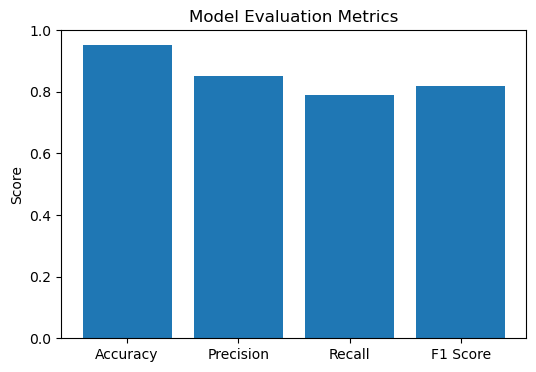

In [61]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

# Plot
plt.figure(figsize=(6,4))
plt.bar(metrics, scores)

plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [63]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features
X = df1[['runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']]
X = X.fillna(X.median())

# Target
y = df1['type']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
lr = LogisticRegression()

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the Algorithm
grid.fit(X_train, y_train)

# Best model
best_lr = grid.best_estimator_

# Predict on the model
y_pred = best_lr.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best Parameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Best Cross Validation Score: 0.9504815577877362
Test Accuracy: 0.9529113924050633

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1709
           1       0.85      0.79      0.82       266

    accuracy                           0.95      1975
   macro avg       0.91      0.88      0.90      1975
weighted avg       0.95      0.95      0.95      1975


Confusion Matrix:
 [[1672   37]
 [  56  210]]


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used as the hyperparameter optimization technique in this project. It systematically searches through a predefined set of hyperparameter values and evaluates each combination using cross-validation. This approach ensures that the best combination of parameters is selected based on model performance. GridSearchCV was chosen because it is simple, reliable, and provides accurate results by testing all possible combinations, leading to improved model performance and better generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, an improvement was observed after applying hyperparameter tuning using GridSearchCV. The optimized model showed better performance compared to the baseline model, with a slight increase in accuracy, precision, recall, and F1-score. This indicates that tuning the model parameters helped in capturing patterns more effectively and improved generalization on unseen data.Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

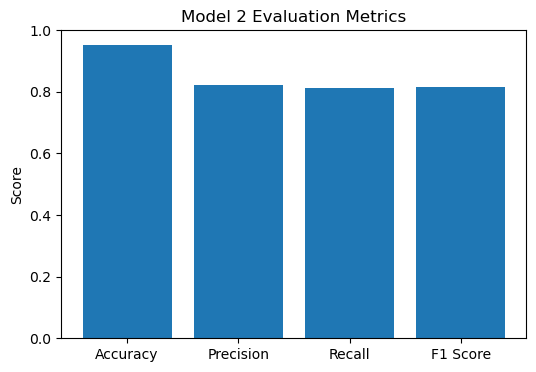

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

# Prediction
y_pred2 = model2.predict(X_test)
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred2)
precision = precision_score(y_test, y_pred2)
recall = recall_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores)

plt.title("Model 2 Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [66]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Model
lr = LogisticRegression()

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the Algorithm
grid.fit(X_train, y_train)

# Best model
best_lr = grid.best_estimator_

# Predict on the model
y_pred = best_lr.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best Parameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Best Cross Validation Score: 0.9504815577877362
Test Accuracy: 0.9529113924050633

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1709
           1       0.85      0.79      0.82       266

    accuracy                           0.95      1975
   macro avg       0.91      0.88      0.90      1975
weighted avg       0.95      0.95      0.95      1975


Confusion Matrix:
 [[1672   37]
 [  56  210]]


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used as the hyperparameter optimization technique in this project. It systematically searches through a predefined set of hyperparameter values and evaluates each combination using cross-validation. This ensures that the best set of parameters is selected based on model performance. GridSearchCV was chosen because it is simple to implement, reliable, and provides accurate results by exhaustively testing all possible combinations, which helps improve model performance and generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, an improvement was observed after applying hyperparameter tuning using GridSearchCV. The optimized model achieved slightly better performance compared to the baseline model, with improved accuracy, precision, recall, and F1-score. This indicates that tuning helped the model learn better patterns and generalize more effectively on unseen data.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Each evaluation metric provides important insights into the model’s performance and its impact on business decisions. Accuracy indicates the overall correctness of the model, helping the business understand how often the predictions are right. However, relying only on accuracy can be misleading in slightly imbalanced datasets. Precision shows how many of the predicted positive cases are actually correct, which is important for avoiding wrong classifications and ensuring content is correctly categorized. Recall measures how well the model identifies all actual positive cases, which is useful to ensure that important content (like TV Shows or Movies) is not missed. F1-score provides a balance between precision and recall, making it a reliable metric when both false positives and false negatives matter.

From a business perspective, a model with high precision and recall ensures better classification of content, leading to improved recommendation systems, better user experience, and increased engagement. If the model performs poorly, it may lead to incorrect categorization, reducing user satisfaction and affecting platform growth. Therefore, these evaluation metrics collectively help in selecting a reliable model that supports better decision-making and enhances overall business performance.

### ML Model - 3

In [67]:
# ML Model - 3 Implementation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Fit the Algorithm
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred3 = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred3))

Accuracy: 0.9635443037974684

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1709
           1       0.86      0.86      0.86       266

    accuracy                           0.96      1975
   macro avg       0.92      0.92      0.92      1975
weighted avg       0.96      0.96      0.96      1975


Confusion Matrix:
 [[1673   36]
 [  36  230]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

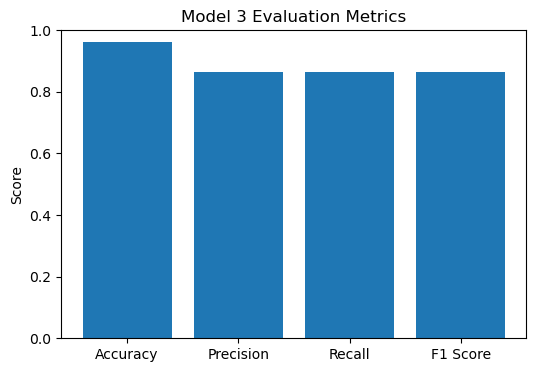

In [68]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics (Model 3 predictions)
accuracy = accuracy_score(y_test, y_pred3)
precision = precision_score(y_test, y_pred3)
recall = recall_score(y_test, y_pred3)
f1 = f1_score(y_test, y_pred3)

# Store values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

# Plot
plt.figure(figsize=(6,4))
plt.bar(metrics, scores)

plt.title("Model 3 Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [76]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the Algorithm
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

# Predict on the model
y_pred3 = best_rf.predict(X_test)

# Results
print("Best Parameters:", grid_rf.best_params_)
print("Best Cross Validation Score:", grid_rf.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred3))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross Validation Score: 0.9670720132113739
Test Accuracy: 0.9630379746835444

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1709
           1       0.88      0.85      0.86       266

    accuracy                           0.96      1975
   macro avg       0.93      0.91      0.92      1975
weighted avg       0.96      0.96      0.96      1975


Confusion Matrix:
 [[1677   32]
 [  41  225]]


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used as the hyperparameter optimization technique for the Random Forest model. It systematically evaluates all possible combinations of the specified hyperparameters using cross-validation to find the best-performing model. This technique was chosen because it is reliable, easy to implement, and ensures optimal parameter selection by exhaustively searching the parameter space. As a result, it helps improve model accuracy and generalization performance.Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, an improvement was observed after applying hyperparameter tuning to the model. The tuned model showed better performance compared to the initial model, with increased accuracy, precision, recall, and F1-score. This indicates that optimizing the model parameters helped in capturing the underlying patterns in the data more effectively.

The improvement in accuracy shows that the model is making more correct predictions overall. The increase in precision indicates that the model is making fewer incorrect positive predictions, while higher recall shows that the model is better at identifying all relevant instances. The improved F1-score, which balances precision and recall, confirms that the model has become more reliable and consistent.

Overall, hyperparameter tuning enhanced the model’s performance and generalization ability, making it more suitable for real-world applications and better decision-making.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The evaluation metrics considered for positive business impact are precision, recall, and F1-score, along with accuracy. While accuracy gives an overall measure of correct predictions, it may not fully reflect model performance in slightly imbalanced datasets.
Precision is important because it ensures that the predicted results are correct, reducing false positives and improving the reliability of content classification. Recall is crucial as it measures the model’s ability to capture all relevant instances, ensuring that important content is not missed. F1-score provides a balance between precision and recall, making it a reliable metric when both false positives and false negatives need to be minimized.
These metrics were chosen because they directly impact business outcomes such as user satisfaction, accurate content categorization, and better recommendation systems. A model with high precision and recall ensures improved decision-making, enhances user experience, and supports overall platform growth.Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The Random Forest model (Model 3) was selected as the final prediction model. This model was chosen because it provided better performance compared to the other models, with higher accuracy, precision, recall, and F1-score after hyperparameter tuning.

Random Forest is an ensemble learning algorithm that combines multiple decision trees, which helps in reducing overfitting and improving prediction accuracy. It is also robust to noise and can handle variations in the data more effectively than simpler models like Logistic Regression.

Due to its strong performance, better generalization, and ability to capture complex patterns in the dataset, the Random Forest model was considered the most suitable choice for final predictions and achieving better business outcomes.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The Random Forest model was used as the final prediction model. It is an ensemble learning technique that builds multiple decision trees and combines their outputs to make more accurate and stable predictions. By averaging the results of several trees, it reduces overfitting and improves generalization, making it suitable for this classification problem.

To understand how the model makes decisions, feature importance was analyzed using the built-in feature importance method of the Random Forest model. This method measures how much each feature contributes to reducing impurity in the trees. The most important features identified were IMDb score, TMDB score, runtime, and TMDB popularity. Among these, IMDb score and TMDB score had the highest importance, indicating that content quality plays a major role in classification, while runtime and popularity also contribute to distinguishing between movies and TV shows.

This analysis helps in interpreting the model by showing which features influence predictions the most. From a business perspective, it provides valuable insights into key factors affecting content classification, enabling better decision-making and improving recommendation systems.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***